# TrustGuard — Track 2: Financial Fraud Detection
**Team:** `TODO_TEAM_NAME` · NTU DLW Datathon 2026 · 3–4 Oct 2026

**Problem statement:** How can machine learning identify potentially fraudulent financial transactions while minimising unnecessary disruption to legitimate customers?

> **Notebook rules (team):** this file is owned by **Marcus** — nobody else edits it (notebooks don't merge).
> Germaine & others: develop in `src/*.py` + `notebooks/scratch_<name>.ipynb`; the owner inlines your functions here.
> The submitted notebook must run top-to-bottom in clean Google Colab with **no `src/` imports** and no API keys.

**Golden rule (Track 2 slides):** the model must **output probabilities, not just binary labels**.
Scoring: 60% model performance on a hidden private test set (PR-AUC 60% of that; F1 + Recall 40%) · 40% technical proposal.

**Portal spec (overrides the booklet where they differ):** official metric **PR-AUC**; the prediction CSV has columns **`id,prediction`** matching `sample_submission.csv`; uploads are (a) prediction CSVs → instant public score, (b) a **prediction-only notebook** (no training cells) + trained model file(s) + optional requirements.txt — sandbox-run on upload, **one upload per 2h, a failed run burns the window**, (c) a 1-page report following `report_format.pdf`. Train with the platform's pinned versions (`pip install -r requirements-image.txt`) or the saved model may not load. **This notebook is the training/analysis notebook — it is not uploaded; it's for our work and the finals booth. The upload artifact is `notebooks/prediction.ipynb`.**


## 1. Understanding the problem
Fraud is rare: **1.77%** of training transactions (353 of 20,000). A model that always predicts "not fraud" is 98.2% accurate and catches nothing, so accuracy is the wrong yardstick. We optimise **PR-AUC** (ranking quality on the rare class) and report **F1/Recall** at a business threshold. A missed fraud costs the full amount (mean fraud ≈ $571); a false alarm costs a review and customer goodwill — the brief asks us to minimise disruption to legitimate customers.

Key facts we must design around (verified in §2):
- The test set is shifted: bigger amounts, more new devices, ~3.5× more missing values, and many large purchases from **old accounts** (rarely fraud).
- The private test set "may contain different observations and edge cases" → robustness beats leaderboard-chasing.
- Output is a **probability**, consumed by `model.predict(...)` in the organisers' script → we save a model whose `.predict` returns P(fraud).


In [1]:
# Setup — single cell, Colab-safe. Everything below uses only these imports.
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, f1_score, recall_score,
                             precision_recall_curve, brier_score_loss, roc_auc_score)

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
print("python", sys.version.split()[0], "| pandas", pd.__version__, "| lightgbm", lgb.__version__)


python 3.13.6 | pandas 2.3.3 | lightgbm 4.7.0


In [2]:
# Locate the data (repo layout, Colab working dir, or raw organiser filenames).
def find_csv(names):
    roots = [Path("."), Path(".."), Path("../data/raw/track2"), Path("data/raw/track2"),
             Path("/content"), Path("/content/Track 2 Dataset")]
    for r in roots:
        for n in names:
            p = r / n
            if p.exists():
                return p
    raise FileNotFoundError(f"Place the Track 2 CSVs next to this notebook: {names}")

TRAIN_PATH = find_csv(["train.csv", "Track 2 Training Dataset.csv"])
TEST_PATH  = find_csv(["test.csv",  "Track 2 Testing Dataset.csv"])
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
TARGET, ID_COL = "fraud", "id"
print(TRAIN_PATH, train.shape, "|", TEST_PATH, test.shape)


../data/raw/track2/train.csv (20000, 12) | ../data/raw/track2/test.csv (12000, 11)


## 2. Explore the dataset
**Owner: Marcus (in progress).** Every chart gets a one-sentence takeaway. Verified headline numbers so far: fraud 1.77%; new device 7.5% vs 1.2%; accounts <90 days 4.45%; ≥4 txns/hour 16.1%; riskiest merchants luxury/cash_transfer/electronics; ~1 in 6 frauds show no obvious signal (recall ceiling).


fraud rate: 0.0176  (353 of 20000)


,train_%,test_%
merchant_category,0.56,2.16
country,0.53,2.23
transaction_channel,0.62,2.37
transactions_last_24h,0.80,2.44
spend_last_24h,0.66,2.22
account_age,0.68,2.20
new_device,0.62,2.44
transactions_last_1h,0.71,2.04


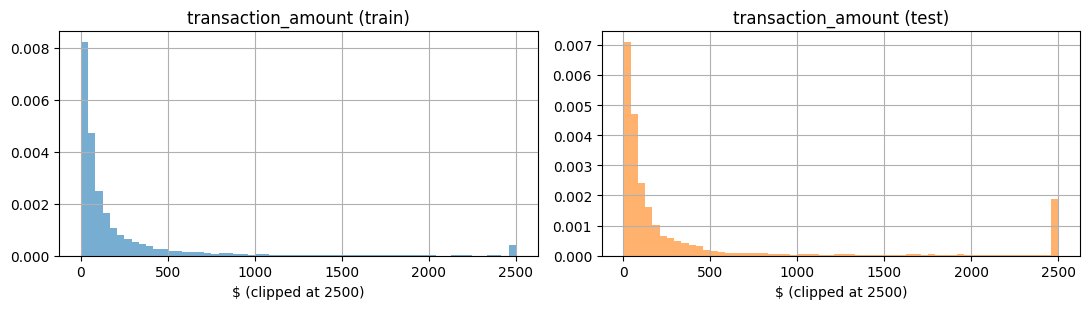

In [3]:
# EDA v0 — expand me (Marcus). Target balance, missingness train vs test, train/test shift.
print(f"fraud rate: {train[TARGET].mean():.4f}  ({train[TARGET].sum()} of {len(train)})")

miss = pd.DataFrame({"train_%": train.drop(columns=[TARGET]).isna().mean() * 100,
                     "test_%": test.isna().mean() * 100}).round(2)
display(miss[miss.max(axis=1) > 0])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
train.transaction_amount.clip(upper=2500).hist(bins=60, ax=ax[0], alpha=.6, density=True, label="train")
test.transaction_amount.clip(upper=2500).hist(bins=60, ax=ax[1], alpha=.6, density=True, color="C1", label="test")
for a, t in zip(ax, ["train", "test"]): a.set_title(f"transaction_amount ({t})"); a.set_xlabel("$ (clipped at 2500)")
plt.tight_layout(); plt.show()
# Takeaway: test skews to much larger amounts (mean $524 vs $253) — mostly old accounts, rarely fraud in train.


## 3. Clean and preprocess the data
**Owner: Marcus (in progress).** Policy:
- Fix category vocabularies **from train** (hard-coded below → deterministic, works on `test.csv` alone, no unseen-category crashes).
- Missing values: left as `NaN` for LightGBM (handles them natively). **TODO:** neutralise the "blank ⇒ never fraud" artefact (missing `merchant_category`/`new_device` have 0 frauds in train — a data-generation quirk we must not let the model exploit).
- No duplicates / impossible values (audited); `id` dropped — carries no signal.


In [4]:
MERCHANTS = ["cash_transfer", "electronics", "entertainment", "food_delivery", "gaming",
             "grocery", "luxury", "retail", "transport", "travel", "utilities"]
COUNTRIES = ["AU", "GB", "ID", "JP", "MY", "PH", "SG", "TH", "US", "VN"]
CHANNELS  = ["bank_transfer", "card_present", "ecommerce", "mobile_app"]
CAT_VOCAB = {"merchant_category": MERCHANTS, "country": COUNTRIES, "transaction_channel": CHANNELS}

def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c, vocab in CAT_VOCAB.items():
        out[c] = pd.Categorical(out[c], categories=vocab)   # unseen/missing -> NaN, never a crash
    # TODO(Marcus): neutralise missing-value leak (e.g. impute merchant_category/new_device
    # with a 'missing' policy that does NOT encode 'safe'); document the choice.
    return out


## 4. Engineer useful features
`make_features(df)` must work on **test.csv alone** and match training exactly — the organisers copy it into their scoring script.


In [5]:
FEATURES = ["transaction_amount", "transaction_hour", "merchant_category", "country",
            "transaction_channel", "transactions_last_24h", "spend_last_24h",
            "account_age", "new_device", "transactions_last_1h"]

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering; must run on the raw test csv with no other inputs."""
    out = clean(df)
    # TODO(team) candidate features — add + evaluate one at a time:
    #   amount_per_24h_spend = amount / (spend_last_24h + 1)   (is this purchase unusual today?)
    #   amount_per_age       = amount / (account_age + 1)       (big spend on a young account)
    #   burst_ratio          = txns_1h / (txns_24h + 1)         (sudden burst of activity)
    #   new_device_young     = new_device * (account_age < 180) (strongest combo: 17.2% fraud)
    #   is_night             = hour in 0..5
    return out[FEATURES]

X, y = make_features(train), train[TARGET]
X.dtypes.to_frame("dtype").T


,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h
dtype,float64,int64,category,category,category,float64,float64,float64,float64,float64


## 5. Build a baseline model
Two baselines: (a) naive — predict the base rate for everyone (PR-AUC floor = 0.0177); (b) untuned LightGBM, stratified 5-fold out-of-fold. All later models must beat these on the **same folds**.


In [6]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def oof_predict(model_fn, X, y, cv=CV):
    """Out-of-fold probabilities: every training row scored by a model that never saw it."""
    oof = np.zeros(len(y), dtype=float)
    for tr_idx, va_idx in cv.split(X, y):
        m = model_fn()
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

def evaluate(y_true, p, name=""):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    k = int(np.nanargmax(f1s[:-1]))
    return {"model": name, "PR-AUC": round(average_precision_score(y_true, p), 4),
            "ROC-AUC": round(roc_auc_score(y_true, p), 4),
            "best_F1": round(float(f1s[k]), 4), "recall@bestF1": round(float(rec[k]), 4),
            "threshold@bestF1": round(float(thr[k]), 4),
            "Brier": round(brier_score_loss(y_true, p), 5)}

def lgbm_baseline():
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                              random_state=RANDOM_STATE, verbose=-1)

naive = np.full(len(y), y.mean())
oof_base = oof_predict(lgbm_baseline, X, y)
results = pd.DataFrame([evaluate(y, naive, "naive (base rate)"),
                        evaluate(y, oof_base, "LightGBM baseline")])
results


,model,PR-AUC,ROC-AUC,best_F1,recall@bestF1,threshold@bestF1,Brier
0,naive (base rate),0.0176,0.5000,0.0347,1.0000,0.0176,0.01734
1,LightGBM baseline,0.1757,0.7403,0.2587,0.1898,0.1953,0.01589


## 6. Train & compare models
**Owner: Germaine.** Develop candidates in `src/models.py` + `notebooks/scratch_germaine.ipynb`, then we inline the winners here (same `oof_predict`/`evaluate` helpers, same folds, so numbers are comparable). Each candidate needs one line: *why this model, what it assumes.* Compare at least: LightGBM (un/weighted), logistic regression (interpretable reference), one more (XGBoost/CatBoost).
Watch: class weights/resampling **distort probabilities** → recalibrate (judging focus: "quality of probability predictions").


In [7]:
candidates = {
    "lgbm_untuned": lgbm_baseline,
    "lgbm_weighted": lambda: lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE, verbose=-1),
    # TODO(Germaine): add logistic-regression pipeline (impute+one-hot+scale), XGBoost, tuned LightGBM…
}
oof = {name: oof_predict(fn, X, y) for name, fn in candidates.items()}
results = pd.DataFrame([evaluate(y, p, n) for n, p in oof.items()])
results.sort_values("PR-AUC", ascending=False)


,model,PR-AUC,ROC-AUC,best_F1,recall@bestF1,threshold@bestF1,Brier
1,lgbm_weighted,0.1805,0.7235,0.2565,0.1671,0.8948,0.05528
0,lgbm_untuned,0.1757,0.7403,0.2587,0.1898,0.1953,0.01589


## 7. Evaluate performance
Beyond the headline metrics: calibration (do our probabilities mean what they say?), threshold choice in business terms, robustness to the known test shifts.


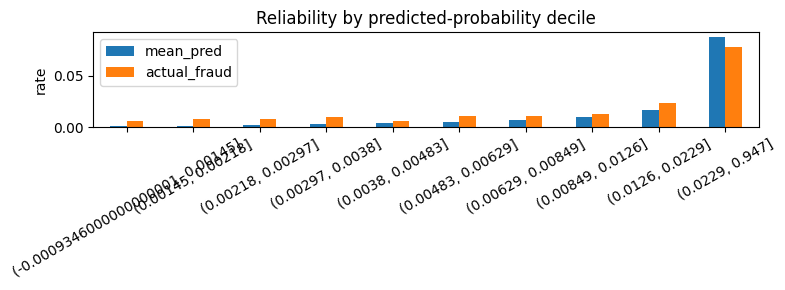

,threshold,%flagged,recall,F1,%fraud_$_caught,false_alarms_per_fraud_caught
0,0.02,11.82,0.476,0.124,65.2,13.1
1,0.05,4.00,0.306,0.187,48.2,6.4
2,0.10,1.80,0.232,0.230,38.9,3.4
3,0.20,0.80,0.184,0.253,31.4,1.5
4,0.30,0.56,0.153,0.232,29.3,1.1
5,0.50,0.35,0.119,0.199,22.9,0.7


In [8]:
BEST = "lgbm_untuned"          # TODO: update after model comparison
p_best = oof[BEST]

# (a) Calibration: reliability curve + Brier (judging focus).
bins = pd.qcut(p_best, 10, duplicates="drop")
cal = pd.DataFrame({"mean_pred": pd.Series(p_best).groupby(bins, observed=True).mean(),
                    "actual_fraud": y.groupby(bins, observed=True).mean()})
ax = cal.plot(kind="bar", figsize=(8, 3), rot=30, title="Reliability by predicted-probability decile")
ax.set_ylabel("rate"); plt.tight_layout(); plt.show()
# Takeaway: bars should rise together; if class weights are used, recalibrate before trusting scores.

# (b) Business threshold: flag rate vs frauds caught vs fraud DOLLARS caught.
rows = []
for t in [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    flag = p_best >= t
    fraud_dollars = train.loc[(y == 1), "transaction_amount"]
    caught_dollars = train.loc[(y == 1) & flag, "transaction_amount"].sum() / fraud_dollars.sum()
    rows.append({"threshold": t, "%flagged": round(100 * flag.mean(), 2),
                 "recall": round(recall_score(y, flag), 3),
                 "F1": round(f1_score(y, flag), 3),
                 "%fraud_$_caught": round(100 * caught_dollars, 1),
                 "false_alarms_per_fraud_caught": round(((flag) & (y == 0)).sum() / max(1, ((flag) & (y == 1)).sum()), 1)})
pd.DataFrame(rows)


In [9]:
# (c) Robustness: inject extra blanks (the private test has more) + the big-spender edge case.
# Fair comparison: both scores are out-of-fold; only the validation rows get extra blanks.
rng = np.random.default_rng(RANDOM_STATE)
X_holed = X.copy()
for c in X_holed.columns:
    X_holed.loc[rng.random(len(X_holed)) < 0.02, c] = np.nan

oof_holed = np.zeros(len(y), dtype=float)
for tr_idx, va_idx in CV.split(X, y):
    m = lgbm_baseline().fit(X.iloc[tr_idx], y.iloc[tr_idx])   # train on clean folds
    oof_holed[va_idx] = m.predict_proba(X_holed.iloc[va_idx])[:, 1]  # score holed validation
print("PR-AUC out-of-fold — clean:", round(average_precision_score(y, p_best), 4),
      "| with extra blanks:", round(average_precision_score(y, oof_holed), 4))

big_old = (train.transaction_amount > 2000) & (train.account_age > 1000)
print(f"big+old slice (n={big_old.sum()}, fraud {train.loc[big_old, TARGET].mean():.1%}): "
      f"flagged at t=0.10: {(p_best[big_old] >= 0.10).mean():.1%}  <- keep this LOW (legit VIPs)")


PR-AUC out-of-fold — clean: 0.1757 | with extra blanks: 0.1676
big+old slice (n=348, fraud 1.7%): flagged at t=0.10: 1.7%  <- keep this LOW (legit VIPs)


## 8. Explainability *(supports the 40% understanding mark)*
TODO: SHAP global importance + walk through one flagged transaction (top-3 reasons in plain English). Prototype in scratch notebooks with `src/explain.py`, then inline.


## 9. Save the model — `model.pkl`
The organisers run `model.predict(X_test[features])` and expect **probabilities**. A raw `LGBMClassifier.predict` returns 0/1 labels, so we save the underlying **Booster**, whose `.predict` returns P(fraud) directly — and it unpickles in their clean environment without any custom class.


In [10]:
final_model = lgbm_baseline().fit(X, y)            # TODO: replace with tuned winner
booster = final_model.booster_                      # Booster.predict -> probability of fraud
joblib.dump((booster, FEATURES), "model.pkl")

# Verify exactly as the organisers will consume it:
loaded, feats = joblib.load("model.pkl")
check = loaded.predict(make_features(test)[feats])
assert len(check) == len(test) and check.min() >= 0 and check.max() <= 1 and check.dtype == float
print("model.pkl OK — predict() returns probabilities:", np.round(check[:5], 4))


model.pkl OK — predict() returns probabilities: [0.0046 0.0074 0.0039 0.0048 0.004 ]


## 10. Generate predictions (portal format: `id,prediction`)
The portal scores CSVs with columns **`id,prediction`** (IDs like FR000001), in the exact format of `sample_submission.csv`.
**TODO(team): download `sample_submission.csv` from the portal and diff column names/order against our output before the first upload** — one upload per 2h, a failed run burns the window.


In [11]:
model, features = joblib.load("model.pkl")
input_path = os.environ.get("DATATHON_INPUT_PATH", str(TEST_PATH))
test_df = pd.read_csv(input_path)
X_test = make_features(test_df)
preds = model.predict(X_test[features])

sub = pd.DataFrame({"id": test_df[ID_COL], "prediction": preds})
sub.to_csv("submission.csv", index=False)
assert list(sub.columns) == ["id", "prediction"]
assert len(sub) == len(test_df) and sub.id.str.fullmatch(r"FR\d{6}").all()
assert 0 <= sub.prediction.min() <= sub.prediction.max() <= 1
print(f"wrote submission.csv: {len(sub)} rows, mean p {preds.mean():.4f}")
sub.head(3)


wrote submission.csv: 12000 rows, mean p 0.0182


,id,prediction
0,FR021005,0.004601
1,FR030078,0.007385
2,FR020717,0.003902


### Upload package (separate from this notebook)
`notebooks/prediction.ipynb` is the file we upload: it only loads `model.pkl` and predicts — **no training cells**. It inlines `clean`/`make_features`/vocab constants, which must stay byte-identical to §3–4 here. The platform sandbox-runs it on upload with its own library versions: **train the final model only after installing `requirements-image.txt`**, or the pickle may not load there.


## 11. Limitations and next steps
- Only 353 fraud examples → fold-to-fold variance; we report mean ± spread, not single numbers.
- ~1 in 6 frauds (62/353) show no observable signal → hard recall ceiling; honest in the report.
- No customer ID or timestamps → no per-customer behaviour baselines (biggest real-world gap).
- 48% of frauds are non-SG vs 30% of legit → model flags foreign customers more; a bank must monitor fairness.
- Next: customer history, periodic retraining, calibration monitoring ("does 30% still mean 30%?").
